| Feature           | Type            |
| ----------------- | --------------- |
| Loan_ID           | ID              |
| Gender            | Categorical     |
| Married           | Categorical     |
| Dependents        | Categorical     |
| Education         | Categorical     |
| Self_Employed     | Categorical     |
| ApplicantIncome   | Numerical       |
| CoapplicantIncome | Numerical       |
| LoanAmount        | Numerical       |
| Loan_Amount_Term  | Numerical       |
| Credit_History    | Numerical       |
| Property_Area     | Categorical     |
| Loan_Status       | Target Variable |


# Step 1 : Import Required Libraries

In [1]:
#Data Handing
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Step 2 : Load Dataset

In [5]:
df = pd.read_csv("RF_loan_approve.csv")

print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (289, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,1
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,1
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,1
3,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,1
4,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban,0


# Step 3 : Basic Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            289 non-null    object 
 1   Gender             289 non-null    object 
 2   Married            289 non-null    object 
 3   Dependents         289 non-null    object 
 4   Education          289 non-null    object 
 5   Self_Employed      289 non-null    object 
 6   ApplicantIncome    289 non-null    int64  
 7   CoapplicantIncome  289 non-null    int64  
 8   LoanAmount         289 non-null    float64
 9   Loan_Amount_Term   289 non-null    float64
 10  Credit_History     289 non-null    float64
 11  Property_Area      289 non-null    object 
 12  Loan_Status        289 non-null    int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 29.5+ KB


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000
mean,4637.352941,1528.262976,136.792388,342.671280,0.840830,0.629758
std,4790.683934,2377.599209,59.699582,65.655503,0.366469,0.483707
min,0.000000,0.000000,28.000000,6.000000,0.000000,0.000000
25%,2875.000000,0.000000,102.000000,360.000000,1.000000,0.000000
50%,3833.000000,879.000000,126.000000,360.000000,1.000000,1.000000
75%,5000.000000,2400.000000,158.000000,360.000000,1.000000,1.000000
max,72529.000000,24000.000000,460.000000,480.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Step 4 : Check Target Variable Distribution

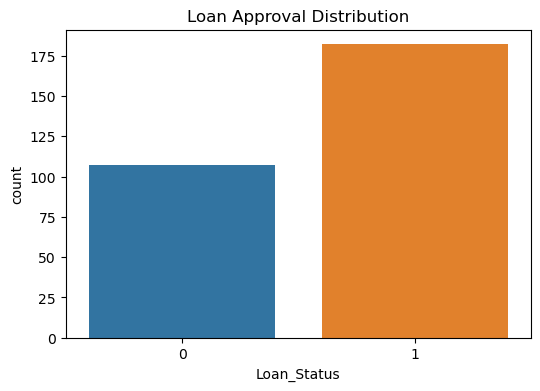

In [9]:
plt.figure(figsize = (6,4))

sns.countplot(x = 'Loan_Status', data = df)

plt.title("Loan Approval Distribution")

plt.show()

# Step 5 : Drop Unnecessary Column

In [10]:
df.drop("Loan_ID", axis = 1, inplace = True)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,1
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,1
3,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,1
4,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban,0


# Step 6 : Convert Categorical Columns into Numeric

In [13]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include = 'object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
    
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,0,0,0,5720,0,110.0,360.0,1.0,2,1
1,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2,1
2,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2,1
3,1,0,0,1,0,3276,0,78.0,360.0,1.0,2,1
4,1,1,0,1,1,2165,3422,152.0,360.0,1.0,2,0


# Step 7 : Correlation Heatmap

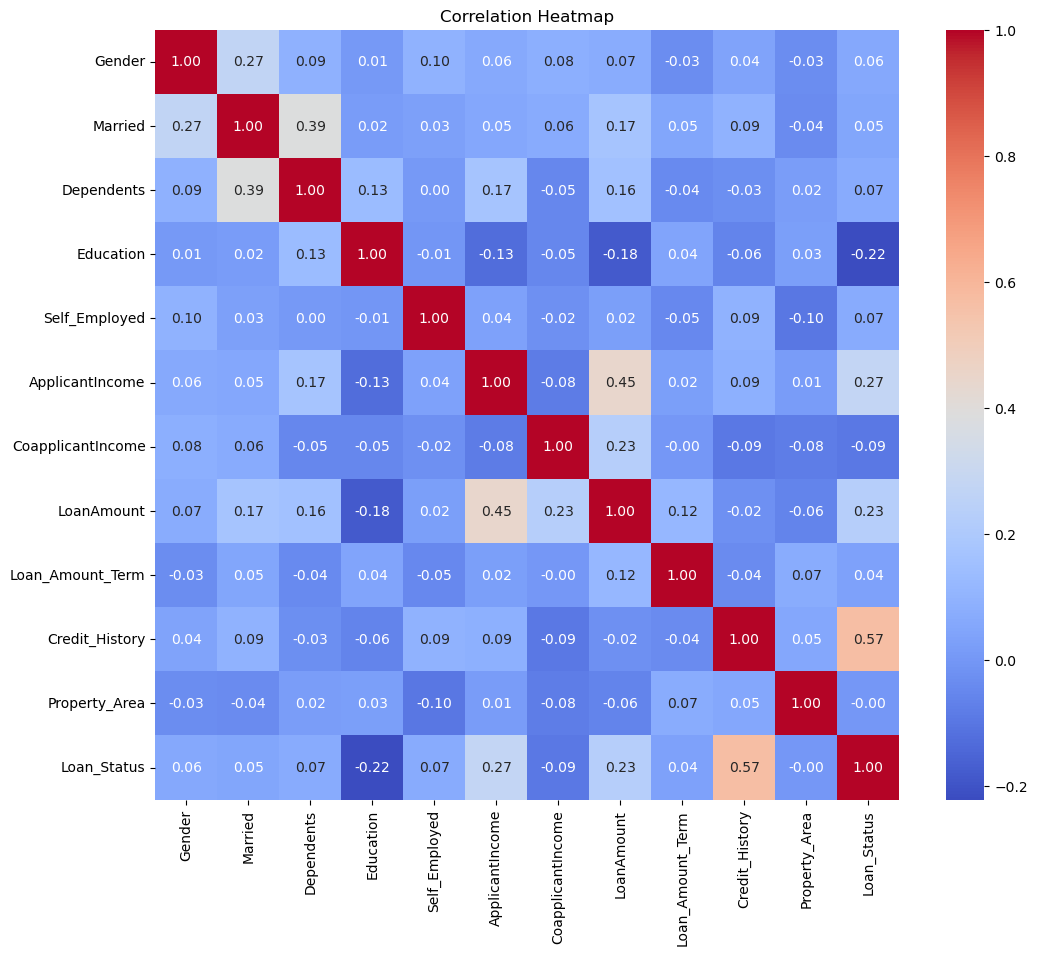

In [15]:
plt.figure(figsize = (12,10))

sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt = ".2f")


plt.title("Correlation Heatmap")
plt.show()

# Step 8 : Separate Features and Target

In [19]:
X = df.drop("Loan_Status", axis = 1)
y = df["Loan_Status"]

# Step 9: Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (231, 11)
Testing Shape : (58, 11)


# Step 10 : Build Random Forest Model

In [21]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 8,
    random_state = 42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

# Step 11: Prediction

In [25]:
y_pred = rf_model.predict(X_test)

print(y_pred[:15])

[1 0 0 0 0 0 1 0 1 0 1 1 1 1 1]


# Step 12: Accuracy Score

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), '%')


Accuracy : 98.28 %


# Step 13 : Confusion Matrix

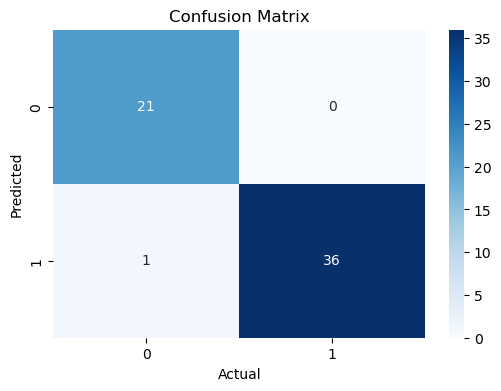

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,4))

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Confusion Matrix")
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.show()

# Step 14: Classification Report

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.99        37

    accuracy                           0.98        58
   macro avg       0.98      0.99      0.98        58
weighted avg       0.98      0.98      0.98        58



# Step 15: Feature importance

In [33]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : importance
})

feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

feature_importance

,Feature,Importance
5,ApplicantIncome,0.510836
9,Credit_History,0.265115
7,LoanAmount,0.075184
6,CoapplicantIncome,0.070242
8,Loan_Amount_Term,0.019738
2,Dependents,0.015619
10,Property_Area,0.014721
3,Education,0.012817
1,Married,0.005635
4,Self_Employed,0.005634


# Step 16: Feature importance Graph

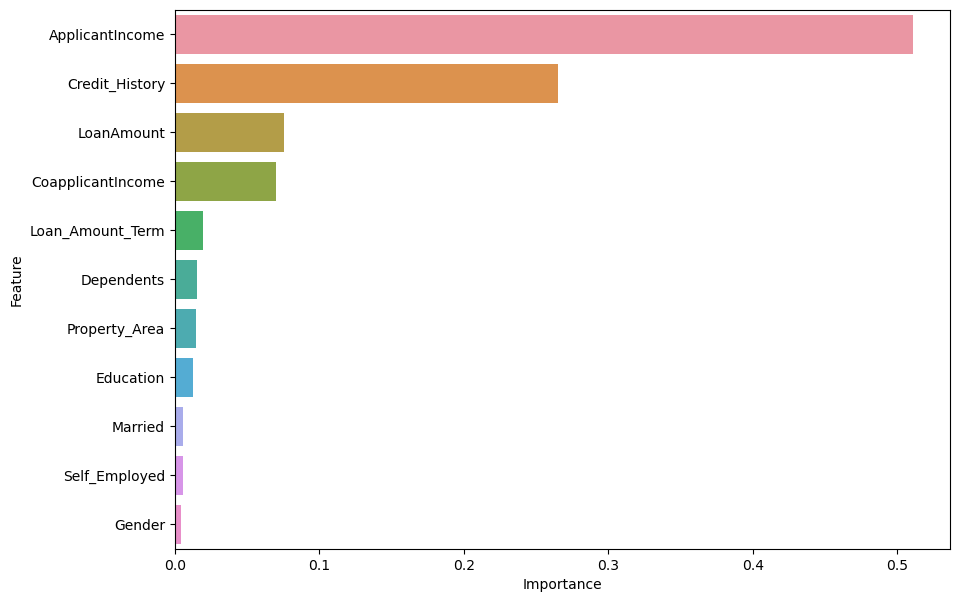

In [34]:
plt.figure(figsize = (10,7))

sns.barplot(x = 'Importance', y = 'Feature', data = feature_importance)

plt.show()

# Step 17: ROC Curve

In [35]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test,y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score :", auc_score)

AUC Score : 1.0


# Step 18: ROC Curve Graph

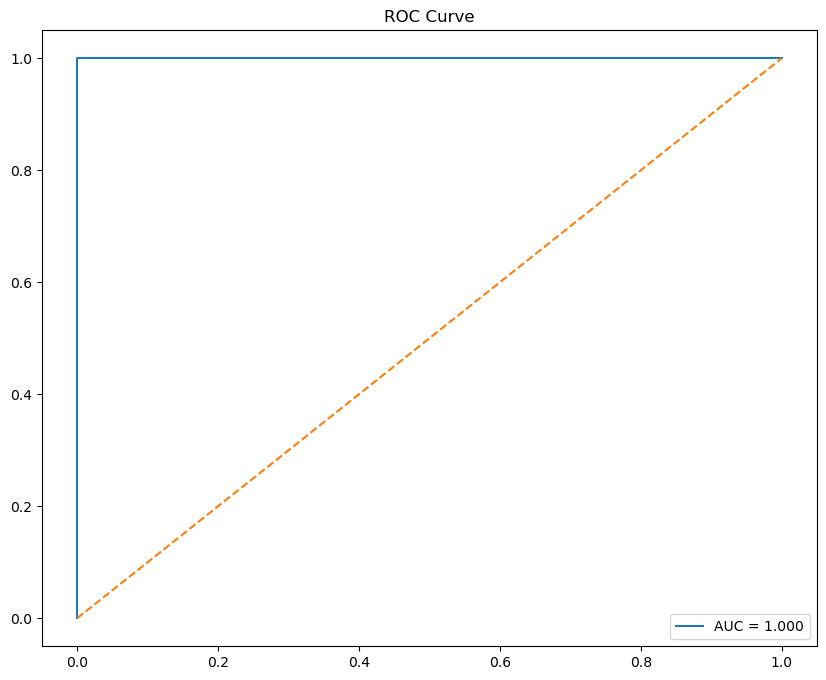

In [37]:
plt.figure(figsize = (10,8))

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle = "--")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Step 19: Actual vs Predicted Comparison

In [38]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})

comparison.head(20)

,Actual,Predicted
69,1,1
101,0,0
157,0,0
6,0,0
50,0,0
243,0,0
57,1,1
217,0,0
109,1,1
5,0,0


# Step 20: Random Forest Tree Visualization

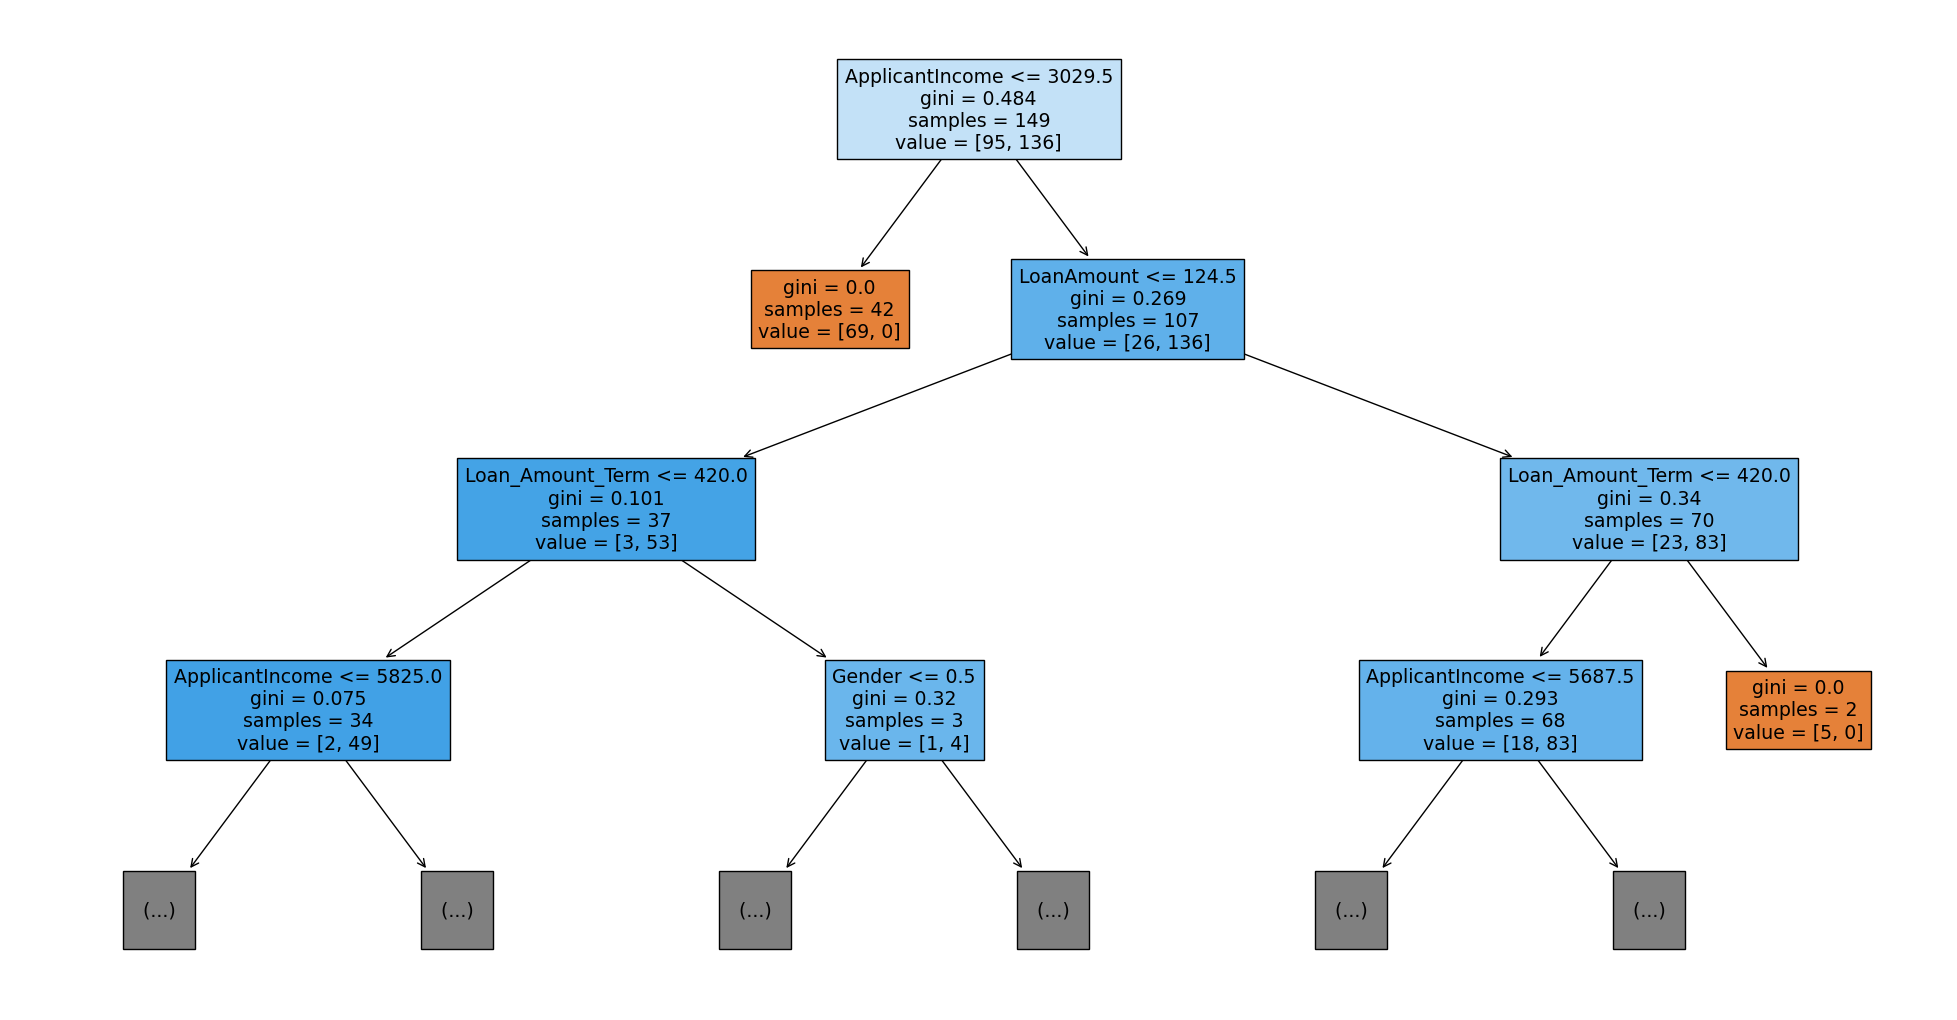

In [39]:
from sklearn.tree import plot_tree

plt.figure(figsize = (25,13))

plot_tree(
    rf_model.estimators_[0],
    feature_names = X.columns,
    filled = True,
    max_depth = 3
)

plt.show()

# Step 21 : Training vs Testing Accuracy (Overfitting Check)

In [41]:
train_pred = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy : 0.9827586206896551


# Step 22: Hyperparameter Tuning Vesion

In [42]:
rf_tuned = RandomForestClassifier(
    n_estimators = 500,
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 2,
    max_features = 'sqrt',
    bootstrap = True,
    random_state = 42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

print("Tuned Accuracy :", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy : 0.9827586206896551
